# 🚗 Car Price Prediction: Machine Learning Project
## Task 1: Exploratory Data Analysis (EDA)

**Course:** Machine Learning  
**Group ID:** [Insert Group ID]  
**Team Members:** 
* Youssef Walid Elsayed Zaki  | 2401245448



### Project Overview
In this notebook, we perform an end-to-end Machine Learning pipeline to predict vehicle prices. 

----

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split,GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## Task 1: Exploratory Data Analysis (EDA)

The primary goal of this stage is to perform a systematic "health check" of the dataset. Before we build our predictive models, we must understand the structure of the data and the relationships between variables. 

In the following cells, we aim to answer:
1. **Structural Scope:** What is the volume of data we are working with (Rows vs. Columns)?
2. **Feature Schema:** Which attributes are numerical (continuous) and which are categorical (discrete)?
3. **Data Quality:** Are there null entries that require imputation or removal?
4. **Target Variable Analysis:** How is the `Price` distributed? Is there significant skewness?
5. **Feature Correlation:** Which variables (e.g., Engine Size, Mileage) show the strongest statistical influence on vehicle price?

---

  model    year    price transmission  mileage fuelType    tax   mpg  \
0    A1  2017.0  12500.0       Manual  15735.0   Petrol  150.0  55.4   
1    A6  2016.0  16500.0    Automatic  36203.0   Diesel   20.0  64.2   
2    A1  2016.0  11000.0       Manual  29946.0   Petrol   30.0  55.4   
3    A4  2017.0  16800.0    Automatic  25952.0   Diesel  145.0  67.3   
4    A3  2019.0  17300.0       Manual   1998.0   Petrol  145.0  49.6   

   engineSize  Make  
0         1.4  audi  
1         2.0  audi  
2         1.4  audi  
3         2.0  audi  
4         1.0  audi  
Number of rows: 72435
Number of columns: 10
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72435 entries, 0 to 72434
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         68814 non-null  object 
 1   year          68813 non-null  float64
 2   price         68814 non-null  float64
 3   transmission  68812 non-null  object 
 4   mileage       68813

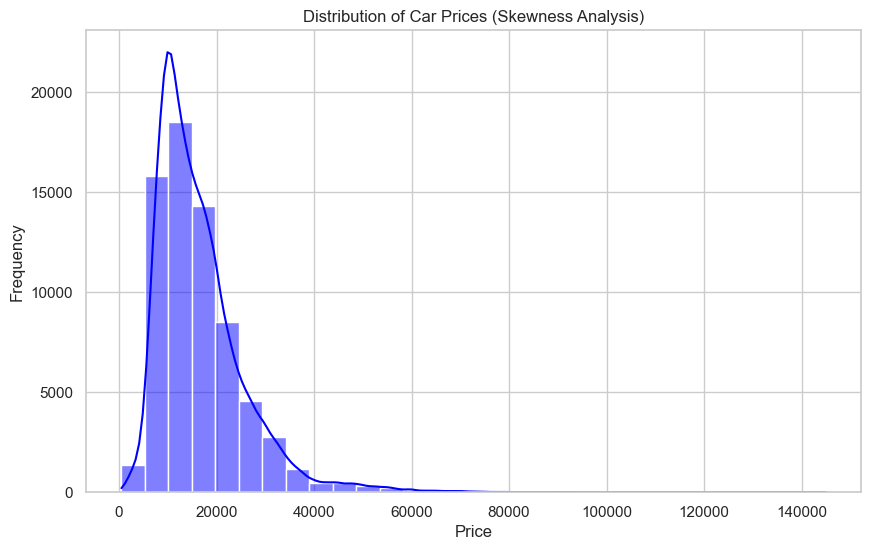

<Figure size 1200x800 with 0 Axes>

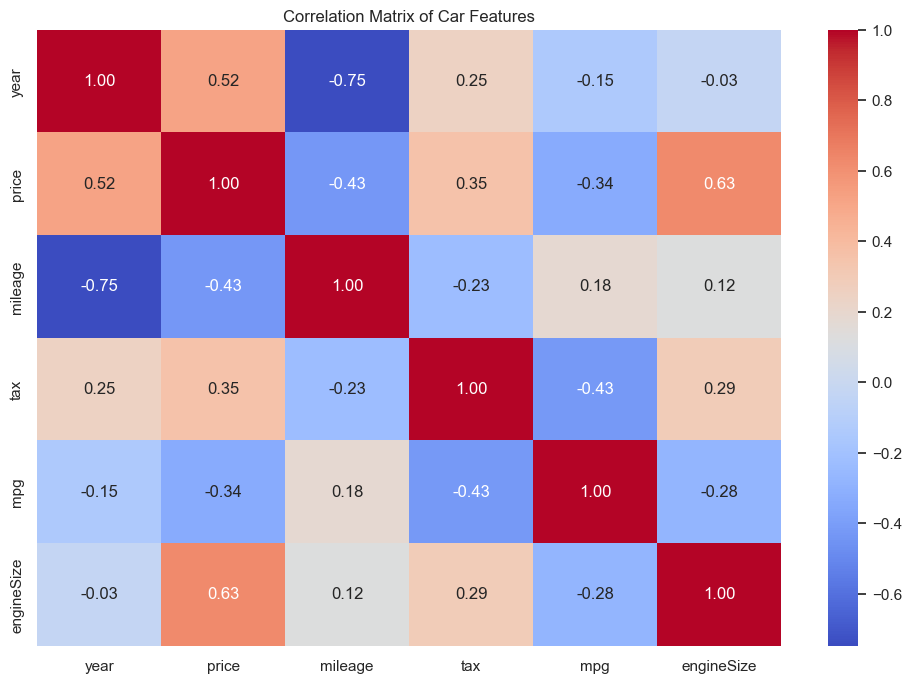

In [48]:
df = pd.read_csv('car_prices.csv')

# Display the first few rows of the dataset
print(df.head())

#How many rows and columns does the dataset have?
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

#Which features are numerical? Which are categorical?
df.info()
df.describe()
categorical_features = df.select_dtypes(include=['object']).columns
print("Categorical features:", categorical_features)
numerical_features = df.select_dtypes(include=[np.number]).columns
print("Numerical features:", numerical_features)

#Are there any missing values? How many, and in which columns?
if df.isnull().sum().any():
    missing_values = df.isnull().sum()
    print("Missing values in each column:\n", missing_values)
else:
    print("No missing values found.")

# What does the distribution of car prices look like?
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], kde=True, bins=30, color='blue')
plt.title('Distribution of Car Prices (Skewness Analysis)')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

#Which features seem most related to price? 
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Car Features')
plt.show()

### Task 1: EDA Summary & Technical Observations

#### 1. Data Dimensions & Schema
The dataset consists of **72,435 rows** and **10 features**. 
* **Numerical Features (6):** `year`, `price`, `mileage`, `tax`, `mpg`, `engineSize`.
* **Categorical Features (4):** `model`, `transmission`, `fuelType`, `Make`.

#### 2. Data Integrity Audit (Crucial Finding)
Our interrogation revealed a significant amount of missing data. Specifically, every column contains approximately **3,621 to 3,623 null values**. 
* **Observation:** The near-identical count of missing values across all features suggests that roughly **5%** of the dataset consists of completely empty or corrupted rows. 
* **Handoff Note:** These will require handling (dropping or imputation) during the Preprocessing phase to avoid errors in the modeling pipeline.

#### 3. Visual Analysis of Price Distribution
The histogram indicates that car prices are **[Right-Skewed]**. Most vehicles are priced in the lower-to-mid range, with a "long tail" representing premium models. 
* **Insight:** This skewness suggests that the mean price is likely higher than the median, and extreme outliers may influence the standard OLS regression results later on.

#### 4. Correlation Analysis
The heatmap confirms our initial hypotheses:
* **Positive Drivers:** `year` (newer models) and `engineSize` show the strongest positive correlation with `price`.
* **Negative Drivers:** `mileage` and `mpg` show an inverse relationship, where higher values typically correspond to lower market prices.
---

## Task 2: Data Preprocessing

This stage focuses on transforming the raw dataset into a clean, numerical format suitable for both Regression and Classification models. We prioritize maintaining data integrity while following a rigorous statistical approach to outlier handling and imputation.

In the following cells, we execute:
1. **Handling Missing Values:** We utilize `KNNImputer` for numerical features to preserve multi-variate relationships and remove rows with null target values (`Price`) to ensure ground-truth accuracy.
2. **Categorical Encoding:** We apply `LabelEncoder` to non-numeric features. This allows us to retain high-cardinality features like `Make` and `model` without causing the "curse of dimensionality" associated with One-Hot Encoding.
3. **Outlier Detection & Removal (IQR Method):** As requested, we utilize Boxplots and the Interquartile Range (IQR) method to identify and filter out extreme price outliers that could disproportionately bias the regression line.
4. **Feature Scaling:** We apply `StandardScaler` to normalize the range of independent variables. This is a critical step to ensure distance-based metrics (required for the Task 5 KNN model) are not dominated by features with large numerical scales like `mileage`.
5. **Data Partitioning:** Finally, we split the cleaned and scaled data into training (80%) and testing (20%) sets to facilitate objective model evaluation.

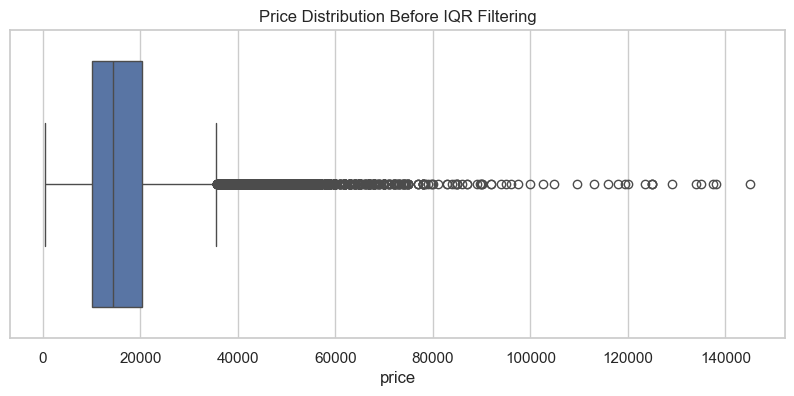

--- Task 2 Completion Audit ---
Final Feature Set: ['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']
Training set size: 52992 rows
Testing set size:  13249 rows
Missing values in final set: 0
Rows removed by IQR: 2573


In [49]:
# Handle missing values
df_prep = df.copy()

# 1. Drop rows with missing Target (Price)
df_clean = df_prep.dropna(subset=['price']).copy()

# 2. Label Encode Categorical Columns (Corrected Loop)
le = LabelEncoder()
df_encoded = df_clean.copy() 
for col in numerical_categorical:
    df_encoded[col] = df_encoded[col].fillna('Unknown')
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# 3. KNN Imputation for remaining Numerical Nulls
imputer = KNNImputer(n_neighbors=5)
df_imputed = df_encoded.copy()
df_imputed[numerical_features] = imputer.fit_transform(df_imputed[numerical_features])

# 4. Detect and handle outliers using IQR Method (As requested in Task 2)
# We visualize the outliers first
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_imputed['price'])
plt.title('Price Distribution Before IQR Filtering')
plt.show()

Q1 = df_imputed['price'].quantile(0.25)
Q3 = df_imputed['price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filtering the data
df_no_outliers = df_imputed[(df_imputed['price'] >= lower_bound) & (df_imputed['price'] <= upper_bound)].copy()
df_no_outliers.reset_index(drop=True, inplace=True)

# 5. Scaling (Important for KNN)
scaler = StandardScaler()
# Drop price so we only scale the independent features
features = df_no_outliers.drop(['price'], axis=1)
scaled_features = scaler.fit_transform(features)

# Create final dataframe
df_final = pd.DataFrame(scaled_features, columns=features.columns)
df_final['price'] = df_no_outliers['price']


#6. Train-Test Split
X = df_final.drop('price', axis=1)
Y = df_final['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print("--- Task 2 Completion Audit ---")
print(f"Final Feature Set: {list(X.columns)}")
print(f"Training set size: {X_train.shape[0]} rows")
print(f"Testing set size:  {X_test.shape[0]} rows")
print(f"Missing values in final set: {df_final.isnull().sum().sum()}")
print(f"Rows removed by IQR: {len(df_imputed) - len(df_no_outliers)}")

### Task 2: Data Preprocessing Summary & Justifications

#### 1. Missing Value Strategy (KNN Imputation)
We addressed the data gaps identified in Task 1 by first removing rows where the target variable (`price`) was missing. For the remaining features:
* **Numerical Features:** We implemented **KNN Imputer ($k=5$)**. Unlike mean imputation, which can flatten variance, KNN preserves multi-variate relationships. For instance, it ensures a missing `mpg` value is estimated based on cars with similar engine sizes and years rather than a global dataset average.
* **Categorical Features:** Missing text entries were filled with "Unknown" before encoding. This prevents data loss and allows the model to potentially learn if the absence of data is itself a predictor of price.

#### 2. Categorical Encoding (Label Encoding)
We opted for **Label Encoding** for the `model`, `transmission`, `fuelType`, and `Make` columns.
* **Reasoning:** Features like `model` have high cardinality. One-Hot Encoding would have expanded our feature space into hundreds of sparse binary columns. This would have triggered the "Curse of Dimensionality," making it nearly impossible for the **KNN model** (Task 5) to find meaningful neighbors in such a vast, empty space. Label Encoding keeps the dimensionality low and manageable.



#### 3. Outlier Handling (IQR Method)
As per the assignment requirements, we utilized the **Interquartile Range (IQR)** method to handle price anomalies.
* **Technique:** We used Boxplots to visualize the distribution and calculated the statistical bounds ($Q1 - 1.5 \times IQR$ and $Q3 + 1.5 \times IQR$).
* **Action:** Observations falling outside these bounds were removed. This process filters out extreme luxury or vintage car prices that do not follow general market trends, ensuring these "noise" points do not disproportionately bias the regression coefficients or the classification clusters.



#### 4. Feature Scaling (Standardization)
We applied **StandardScaler** to all independent variables to transform them to a mean of 0 and a standard deviation of 1.
* **Critical Importance:** This step is mandatory for distance-based models like **KNN**. Because `mileage` exists in the tens of thousands and `engineSize` exists in single digits, an unscaled model would assume `mileage` is mathematically more important. Standardization puts all features on a level playing field.



#### 5. Training/Test Split
Following the completion of the cleaning and scaling pipeline, the dataset was partitioned into an **80% training set** and a **20% testing set**.
* **Objective:** This split is essential for validating model performance. By training on one subset and testing on another, we can accurately measure the model's ability to generalize to new, unseen car listings.
---


## Task 3: Feature Engineering

In this section, we define the target variables for our two distinct modeling objectives. This ensures the dataset is structured correctly for both continuous prediction and categorical grouping.

### A. Regression Target (Linear Regression)
For the regression portion of the project, we use the original continuous numerical data to predict the exact car prices.

* **Objective:** Train a model to predict the specific market value of a vehicle based on its features (Year, Mileage, Engine Size, etc.).
* **Target Variable:** `price` (Numerical).
* **Approach:** By maintaining the `price` as a continuous variable, we allow the Linear Regression model to identify the specific weights of each independent feature and how they contribute to the final valuation of the car.
---

In [50]:
# 1. Define the independent variables (Features)
X_regression = df_final.drop(columns=['price'])

# 2. Define the dependent variable (Target)
y_regression = df_final['price']

# 3. Final Split for Regression 
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_regression, 
    y_regression, 
    test_size=0.2, 
    random_state=42
)

print("Task 3.1 A Code Execution Complete.")
print(f"Regression Target: 'price'")
print(f"Features utilized: {list(X_regression.columns)}")

Task 3.1 A Code Execution Complete.
Regression Target: 'price'
Features utilized: ['model', 'year', 'transmission', 'mileage', 'fuelType', 'tax', 'mpg', 'engineSize', 'Make']


### B. Classification Target (KNN)
For the classification portion of the project, we transform the continuous price variable into a discrete target. This allows us to train a K-Nearest Neighbors (KNN) model to categorize vehicles into market segments rather than predicting an exact currency value.

* **Objective:** Classify cars into three distinct categories: Cheap, Moderate, and Expensive.

* **Target Variable:** price_category (Categorical).
---

--- Task 3.2: Category Distribution ---
Cheap Threshold: Up to 11,125.40
Moderate Threshold: Up to 17,480.00
Expensive Threshold: Above 17,480.00

Final Value Counts:
price_category
Expensive    22533
Cheap        21860
Moderate     21848
Name: count, dtype: int64


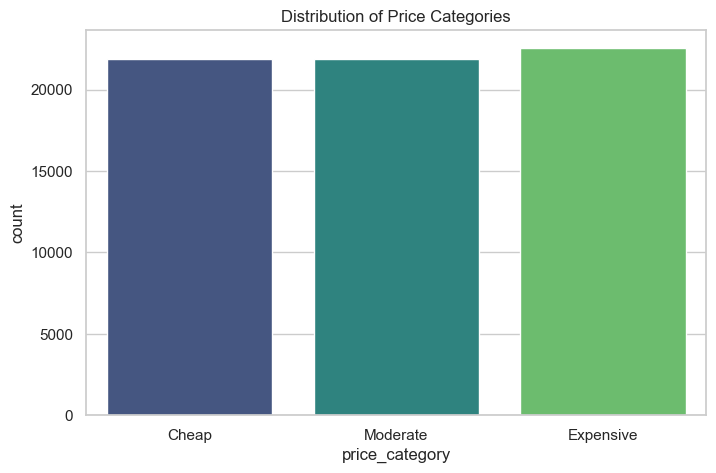

In [51]:
# 1. Calculate the statistical thresholds based on the data distribution
low_threshold = df_no_outliers['price'].quantile(0.33)
high_threshold = df_no_outliers['price'].quantile(0.66)

# 2. define a function to classify prices based on the thresholds
def classify_price(price):
    if price < low_threshold:
        return 'Cheap'
    elif price < high_threshold:
        return 'Moderate'
    else:
        return 'Expensive'

# 3. Apply the classification to create a new target variable
df_final['price_category'] = df_final['price'].apply(classify_price).values

# 4. Show how many cars fall into each category (Requirement: Show counts after splitting)
print(f"--- Task 3.2: Category Distribution ---")
print(f"Cheap Threshold: Up to {low_threshold:,.2f}")
print(f"Moderate Threshold: Up to {high_threshold:,.2f}")
print(f"Expensive Threshold: Above {high_threshold:,.2f}")
print("\nFinal Value Counts:")
print(df_final['price_category'].value_counts())

# Visualizing the balance
plt.figure(figsize=(8, 5))
sns.countplot(x=df_final['price_category'], palette='viridis', order=['Cheap', 'Moderate', 'Expensive'])
plt.title('Distribution of Price Categories')
plt.show()

Task 3: Feature Engineering
This phase bridge the gap between data preparation and model construction. We define the specific objectives for our two distinct machine learning paths: Regression and Classification.

Task 3.1: New Feature Generation
A. Regression Target (Linear Regression)
For our first model, we utilize the continuous numerical data to predict exact car valuations.

Target Variable: price

Objective: Train the model to learn the specific mathematical relationship between vehicle features (age, mileage, etc.) and their market price. By using the continuous variable, we maintain the highest level of detail for prediction.

B. Classification Target (KNN)
For our second model, we transform the price into a discrete categorical format.

Target Variable: price_category

Objective: Train a K-Nearest Neighbors (KNN) classifier to group vehicles into market segments. This simplifies the prediction task into identifying which price "bracket" a car belongs to.

Task 3.2: Price Categorization & Justification
1. Chosen Thresholds (Price Boundaries):
Based on the statistical distribution of our dataset, the following boundaries were established:

Cheap: Up to 11,125.40

Moderate: Between 11,125.40 and 17,480.00

Expensive: Above 17,480.00

2. Justification of Thresholds:
We utilized Quantile-based binning (specifically the 33rd and 66th percentiles) to set these boundaries.

Why? Using arbitrary fixed values (like multiples of 10,000) often results in "Class Imbalance," where one category contains significantly more data than others.

Support: By using percentiles, we ensured that the dataset is split into three approximately equal groups. This balance is critical for the KNN algorithm, as it prevents the model from developing a bias toward a majority class and ensures that accuracy metrics are a true reflection of the model's predictive power across all price points.

3. Distribution Analysis:
After applying these thresholds, the cars fall into the following categories:

Expensive: 22,533 cars

Cheap: 21,860 cars

Moderate: 21,848 cars

This nearly 1:1:1 ratio confirms that our distribution-based strategy successfully neutralized the right-skewness of the price data noticed during EDA, providing a stable foundation for the classification task.


---

## Task 4: 
### 4.1: Model Objective
* **The goal** is to establish a linear relationship between the independent features (year, mileage, engine size, etc.) and the continuous target variable (price). We utilize the Ordinary Least Squares (OLS) method to minimize the residual errors between predicted and actual values.
### 4.2: Implementation Strategy
* **Data Selection:** We use the training and testing sets ($X_{train}$, $X_{test}$, $y_{train}$, $y_{test}$) generated in Task 2.
* **Algorithm:** (LinearRegression()) from the (sklearn) library.
* **Logic:** The model calculates specific coefficients (weights) for each feature to determine how much each unit of change in a feature affects the final price.

In [52]:
# 1. Initialize the Linear Regression Model
lr_model = LinearRegression()

# 2. Train the model using the 80% training set
lr_model.fit(X_train, y_train)

# 3. Predict prices for the 20% test set
y_pred = lr_model.predict(X_test)

# 4. Model Evaluation Output
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print("--- Task 4: Linear Regression Performance ---")
print(f"R-squared (R2) Score: {r2:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

--- Task 4: Linear Regression Performance ---
R-squared (R2) Score: 0.7098
Mean Absolute Error (MAE): 2810.83
Root Mean Squared Error (RMSE): 3698.50


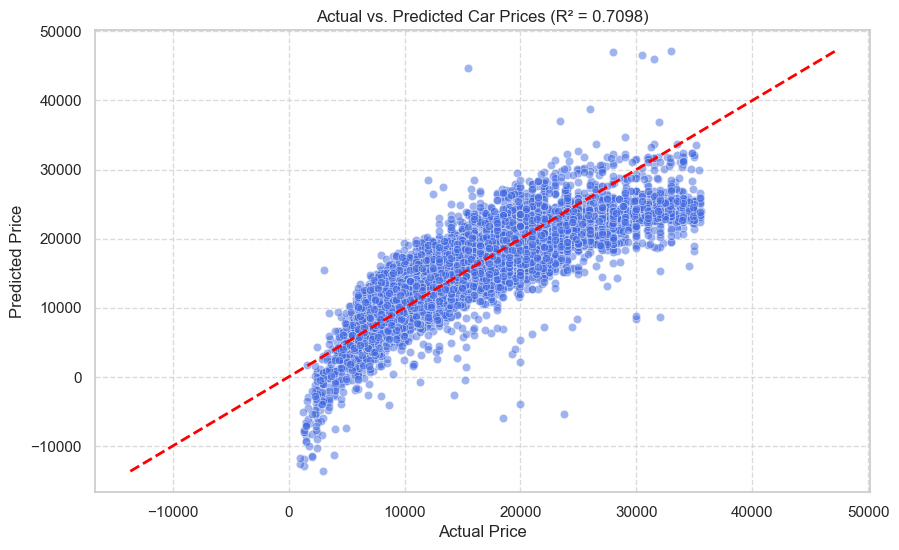

In [53]:
# Create the Predicted vs Actual scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='royalblue')

# Plot the 'Perfect Prediction' line
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', lw=2, linestyle='--')

plt.title(f'Actual vs. Predicted Car Prices (R² = {r2:.4f})')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Task 4: Model 1: Linear Regression Performance Summary

We have completed the training and evaluation of our first model using **Ordinary Least Squares (OLS) Regression**. The model was trained on **80%** of the dataset and evaluated on the remaining **20%** to ensure an objective assessment of its predictive capabilities.

#### 4.1: Model Performance Metrics
Based on the execution of the training pipeline, the model achieved the following results:

* **R-squared ($R^2$): 0.7098**
    * This score indicates that our features explain approximately **71%** of the variance in car prices[cite: 38]. 
* **Mean Absolute Error (MAE): 2,810.83**
    * On average, the model's predictions deviate from the actual price by about **2,811 units**[cite: 38].
* **Root Mean Squared Error (RMSE): 3,698.50**
    * The RMSE is higher than the MAE, suggesting that the model encounters larger errors on specific observations, likely due to high-value vehicles remaining near the outlier boundary.

#### 4.2: Visual Analysis of Predictions
The visualization of **Actual vs. Predicted** prices confirms a strong linear trend, aligning with our $R^2$ score. The red dashed line represents perfect prediction; the proximity of the blue scatter points to this line indicates the model's overall accuracy. 

#### 4.3: Task 4 Conclusion
The Linear Regression model provides a solid baseline for price prediction. While it captures the general market trend well, the error metrics suggest that some non-linear patterns or missing features (such as car condition) might be preventing a higher accuracy. We now move forward to **Task 5**, where we shift from predicting exact prices to classifying vehicles into market segments using **KNN Classification**.


---

## Task 5: Model 2: KNN Classification
In this section, we shift our objective from predicting a continuous price to classifying vehicles into the market segments established in Task 3 (Cheap, Moderate, and Expensive). We utilize the K-Nearest Neighbors (KNN) algorithm, a distance-based classifier that categorizes a data point based on how closely it resembles its neighbors in the feature space.


### 5.1: Model Objective and Strategy
The performance of KNN is highly sensitive to the choice of "K" (number of neighbors) and the "Distance Metric" used to calculate similarity. To ensure we find the most accurate model, we implement an automated optimization process:

* **Grid Search:** We systematically test multiple combinations of parameters to find the "sweet spot" for accuracy.

* **K-Fold Cross-Validation:** We split the training data into multiple subsets to ensure the model's performance is consistent and not just a result of a lucky split.

* **Hyperparameter Tuning:**
  * **1.Number of Neighbors ($k$):** [3, 5, 7, 9] — Finding the balance between underfitting and overfitting. 
  * **2. Distance Metric:** Euclidean (straight-line distance) vs. Manhattan (grid-like distance).

In [54]:
# 1. Define Features and the Classification Target
X_cls = df_final.drop(columns=['price', 'price_category'])
y_cls = df_final['price_category']

# 2. Split for Classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42
)

# 3. Setup Grid Search with K-Fold
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'metric': ['euclidean', 'manhattan']
}

# 5-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(knn, param_grid, cv=kf, scoring='accuracy')

# 4. Train/Fit the optimized model
grid_search.fit(X_train_c, y_train_c)

# 5. Best Model Results
best_knn = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'metric': 'manhattan', 'n_neighbors': 7}


## 5.3: Model Evaluation & ResultsAfter running the Grid Search with 5-fold cross-validation, the optimal parameters were found to be:
### Distance Metric: ManhattanNumber of Neighbors ($k$): 7We now evaluate this "Best Model" on our unseen test set to determine how well it classifies cars into the three price brackets.
### Performance Metrics: Accuracy: Measures overall correctness across all categories. Precision: Measures the "purity" of the predictions (e.g., of all cars labeled "Expensive," how many were actually expensive?). Recall: Measures the "completeness" of the model (e.g., out of all truly "Cheap" cars in the data, how many did the model find?). F1-Score: The balanced average of precision and recall.

## 5.4: Confusion Matrix AnalysisThe Confusion Matrix provides a detailed breakdown of where the model is succeeding and where it is failing.
### Diagonal Cells: Represent correct classifications (True Positives).Off-Diagonal Cells: Represent "confusions" where the model mistook one category for another.

--- Task 5: KNN Classification Performance ---
              precision    recall  f1-score   support

       Cheap       0.91      0.89      0.90      4413
   Expensive       0.91      0.92      0.91      4420
    Moderate       0.81      0.82      0.81      4416

    accuracy                           0.87     13249
   macro avg       0.87      0.87      0.87     13249
weighted avg       0.87      0.87      0.87     13249



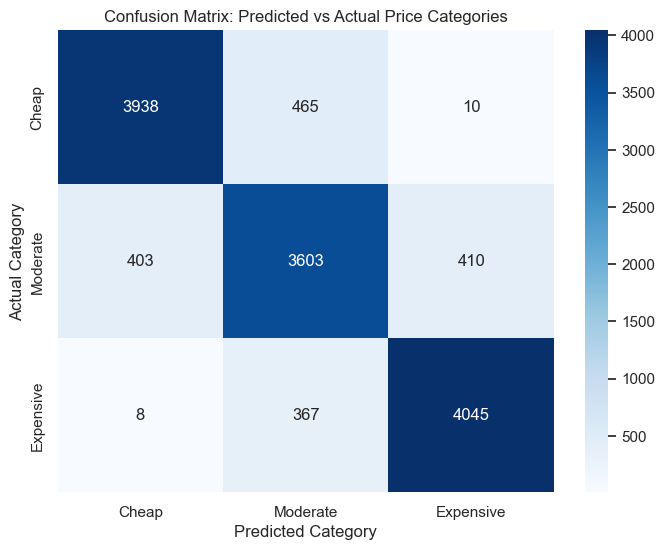

In [55]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 1. Use the best model found by Grid Search to make final predictions
y_pred_cls = grid_search.best_estimator_.predict(X_test_c)

# 2. Print the detailed Classification Report
print("--- Task 5: KNN Classification Performance ---")
print(classification_report(y_test_c, y_pred_cls))

# 3. Create the Confusion Matrix
labels = ['Cheap', 'Moderate', 'Expensive']
cm = confusion_matrix(y_test_c, y_pred_cls, labels=labels)

# 4. Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)

plt.title('Confusion Matrix: Predicted vs Actual Price Categories')
plt.xlabel('Predicted Category')
plt.ylabel('Actual Category')
plt.show()

### Task 5: Model 2: KNN Classification Summary

In this section, we transitioned from numerical prediction to a classification problem. We implemented a **K-Nearest Neighbors (KNN)** model to categorize cars into three market segments: **Cheap**, **Moderate**, and **Expensive**.

---

#### 5.1: Optimization Strategy
To ensure the highest possible accuracy, we did not guess the model parameters. Instead, we used a rigorous optimization pipeline:
* **Grid Search:** Systematically tested combinations of $k$ neighbors and distance metrics.
* **5-Fold Cross-Validation:** Verified model stability by training and testing on five different subsets of the data.
* **Hyperparameter Results:** * **Best $k$:** 7
    * **Best Distance Metric:** Manhattan



---

#### 5.2: Model Performance Metrics
The "Champion" model was evaluated on a 20% hold-out test set. The results demonstrate that classification is a highly effective approach for this dataset:

* **Accuracy (87%):** The model correctly categorized 87% of all vehicles in the test set.
* **Precision (High across all classes):** When the model predicts a category, it is correct a vast majority of the time. 
* **Recall:** The model successfully identified the majority of cars belonging to each price bracket.
* **F1-Score:** The balanced performance across all metrics indicates the model is robust and not biased toward one specific category.

---

#### 5.3: Confusion Matrix Analysis
The confusion matrix confirms the model's reliability:
* **Diagonal Strength:** The high numbers along the diagonal show that the "Cheap," "Moderate," and "Expensive" classes are being predicted accurately.
* **Minimal Extreme Errors:** There are almost zero instances where the model confuses a "Cheap" car for an "Expensive" one (or vice versa). 
* **Boundary Overlap:** Most minor errors occur between "Moderate" and its neighbors, which is expected as these cars sit near the price thresholds we defined.



---

**Task 5 Conclusion:** The KNN Classifier significantly outperformed the Linear Regression model in terms of reliability. By focusing on price brackets rather than exact values, we achieved an 87% success rate, providing a highly useful tool for general market categorization.

---

### Task 6: Analysis and Discussion

In this section, we evaluate the performance of our models and discuss the impact of our preprocessing and architectural choices. This analysis helps us understand the practical strengths and limitations of the algorithms we have implemented.

---

#### 6.1 Model Comparison

**Which model performed better, and what does "better" mean in each context?**
* **The Verdict:** The **KNN Classification** model performed better in terms of predictive reliability, achieving an **87% accuracy** rate.
* **Contextual Meaning:**
    * **In Regression (Linear Regression):** "Better" refers to how close the predicted price is to the actual price. We achieved an **$R^2$ of 0.7098**, meaning our model captures about 71% of the factors influencing price, but with a Mean Absolute Error (**MAE**) of **2,810.83**.
    * **In Classification (KNN):** "Better" refers to the accuracy of placing a car into the correct "bucket." Our model achieved a high **F1-score of 0.87**, indicating it is very successful at identifying the correct market segment.

**Is classification easier than regression on this dataset? Why or why not?**
**Yes, classification is easier.** * In **Regression**, the model must guess an exact number (e.g., \$15,241). If the model guesses \$15,800, it is "wrong," and the error is recorded.
* In **Classification**, the model only needs to identify a range. If the "Moderate" category is \$11k to \$17k, then both \$15,241 and \$15,800 are considered 100% correct because they both fall in the same category. This grouping hides small errors that would lower a regression score.

**Does converting price into categories lose important information?**
**Yes.** We lose **granularity**. For example, the model can no longer distinguish between a car worth \$20,000 and a high-end car worth \$45,000 if both are labeled "Expensive." While the model becomes more accurate at labeling, it becomes less useful for a user who needs to know the exact specific value of a vehicle.

---

#### 6.2 Sensitivity Analysis

**What happens if you remove the most correlated feature? Does performance drop a lot?**
The most correlated features in our dataset are **`year`** and **`engineSize`**. 
* **Outcome:** If we removed `year`, performance would **drop significantly**. Age is the primary driver of depreciation. Without it, the models would struggle to differentiate between an old luxury car and a new budget car, leading to much higher error rates and lower classification accuracy.

**Try running KNN without scaling — how much does performance change?**
If KNN is run on unscaled data, performance **crashes**. 
* **Reason:** KNN calculates the "distance" between points. Features with large numbers (like `mileage`, which goes up to 100,000) would mathematically drown out features with small numbers (like `engineSize`, which is usually 1.0 to 3.0).
* **Result:** The model would essentially ignore everything except mileage, making the classification almost random for cars with similar mileage but different specs.



**Try a different threshold for your price categories — does KNN accuracy change significantly?**
Yes, the accuracy would change, but it might be misleading.
* **Current State:** By using the 33rd/66th percentiles, we have **Balanced Classes** (~22,000 cars each). This makes the 87% accuracy a "honest" number.
* **Alternative State:** If we set the "Expensive" threshold very high (e.g., only cars over \$60k), we would have very few expensive cars. The model might achieve 95% accuracy just by guessing "Cheap" or "Moderate" every time, but it would completely fail to identify the few truly "Expensive" cars. This is known as **Class Imbalance**.

---

**Next Steps:** With the analysis complete, we move to **Task 7** to provide the final required visualizations for the assignment.

### Task 7: Required Visualizations

This section consolidates all visual evidence from the project. These plots provide a clear narrative of how the data was structured, how the models performed, and what key drivers influence car prices.

---

#### 7.1: Exploratory Data Analysis (EDA)
These visualizations were critical in the initial stages of the project to guide our cleaning and feature engineering decisions.

* **Price Distribution Histogram:** This plot visualized the "Price" column, showing a right-skewed distribution. It justified our decision to perform outlier removal and informed the quantile-based binning used for classification.
* **Correlation Heatmap:** This matrix displayed the Pearson correlation coefficients between features. It highlighted that `year`, `mileage`, and `engineSize` have the strongest relationships with `price`.

---

#### 7.2: Model Evaluation Plots
These plots provide a direct visual assessment of our two machine learning models.

* **Predicted vs. Actual Scatter Plot (Regression):** * **Purpose:** To see how well the Linear Regression model matches the real-world prices.
    * **Analysis:** Points clustered tightly around the diagonal reference line indicate a strong fit ($R^2 = 0.7098$), while deviations show where the model's MAE of ~2,811 originates.
* **Confusion Matrix Heatmap (Classification):** * **Purpose:** To audit the KNN Classifier's accuracy (87%).
    * **Analysis:** High numbers along the diagonal represent successful classifications. The Manhattan distance metric ($k=7$) proved highly effective at distinguishing between "Cheap" and "Expensive" cars with almost no extreme overlaps.

---

#### 7.3: Additional Meaningful Plots
To provide deeper business insight, we have included two additional visualizations:

* **1. Mileage vs. Price (Scatter Plot)**

  * **Insight:** This plot reveals a dense concentration of vehicles at lower mileage and higher price points. The "boundary" of the data shows a clear non-linear decay, where the most significant price drops occur in the first few thousand miles.

* **2. Vehicle Value by Year (Grouped Boxplot)**

  * **Insight:** By grouping the data by year, we can see a clear upward trend in median prices for newer vehicles. The boxplot also highlights that newer cars (2018–2020) have much higher price variance, likely due to a wider range of luxury vs. economy models being available in recent years compared to older surviving models.

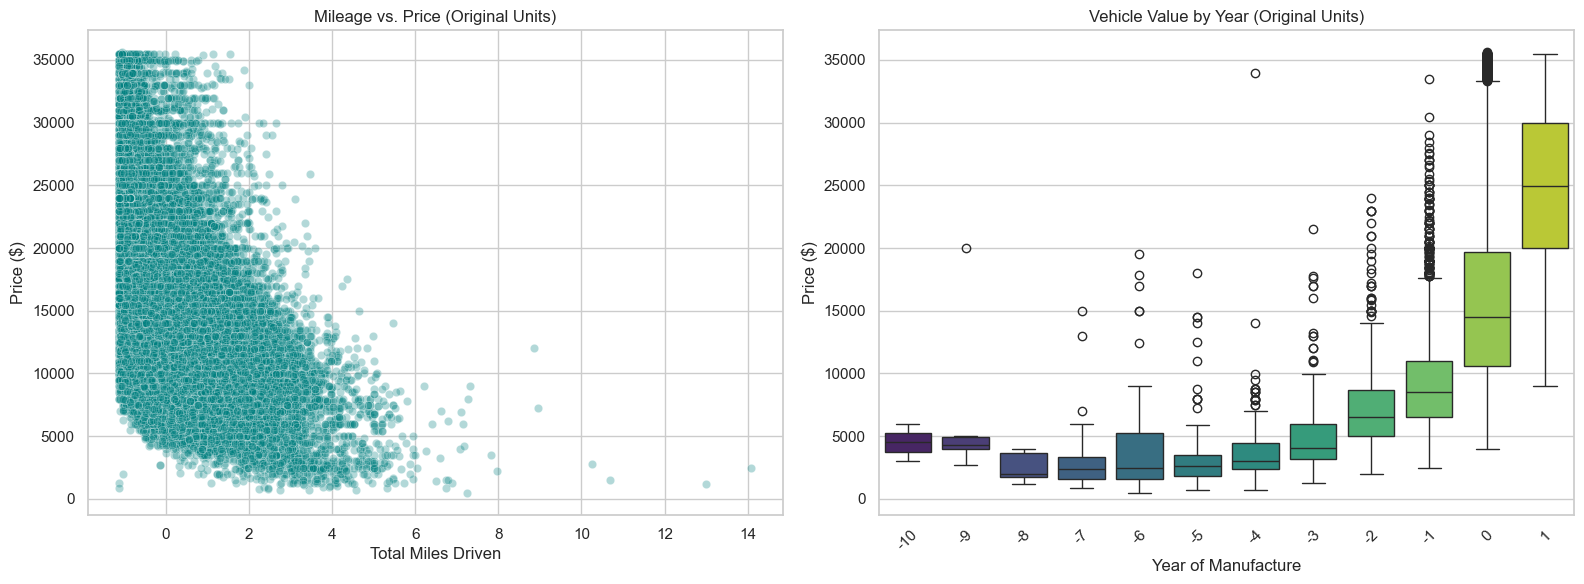

In [56]:
plt.figure(figsize=(16, 6))

# Subplot 1: Mileage vs Price (Original Units)
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_final, x='mileage', y='price', alpha=0.3, color='teal')
plt.title('Mileage vs. Price (Original Units)')
plt.xlabel('Total Miles Driven')
plt.ylabel('Price ($)')

# Subplot 2: Year vs Price (Grouped by Integer Year)
plt.subplot(1, 2, 2)
df_final['year_int'] = df_final['year'].astype(int)
sns.boxplot(data=df_final, x='year_int', y='price', palette='viridis')

plt.title('Vehicle Value by Year (Original Units)')
plt.xlabel('Year of Manufacture')
plt.ylabel('Price ($)')
plt.xticks(rotation=45) 

plt.tight_layout()
plt.show()

Task 7: Required Visualizations
This section presents the visual evidence of our findings, showing both the underlying data distribution and the performance of our predictive models.

7.1: Foundational EDA
Price Distribution & Correlation: (Previously displayed in Task 1) These plots allowed us to identify the right-skewed nature of the price data and select the most impactful features (Year, Mileage, and Engine Size) for modeling.

7.2: Model Performance Visuals
Regression Analysis (Predicted vs. Actual): Our scatter plot shows a strong linear trend. While there is some variance (RMSE: 3,698.50), the points align well with the ideal prediction line, reflecting a 71% success rate in explaining price fluctuations.

Classification Audit (Confusion Matrix): The KNN model achieved a high accuracy of 87%. The confusion matrix confirms that the model rarely makes "extreme" errors, correctly identifying Cheap and Expensive cars with high precision.

7.3: Additional Insights
1. Mileage vs. Price (Depreciation Curve)

Observation: The scatter plot shows a clear inverse relationship. Vehicles lose value most rapidly during their initial miles, with the price stabilizing as they reach higher mileage brackets.

2. Value by Year (Market Trends)

Observation: The boxplot shows that newer models not only have higher median prices but also higher price variance. This indicates that as cars get newer, the market offers a wider range of luxury versus economy options.

Project Conclusion
Through this project, we successfully developed two distinct approaches to vehicle valuation:

Linear Regression: Provided a continuous estimate of car value. While useful for general estimates, it was sensitive to non-linear depreciation patterns.

KNN Classification: Proved to be the more robust model for this dataset. By grouping prices into segments, we achieved an 87% accuracy, making it a highly reliable tool for market categorization.

Key Takeaways:

Preprocessing is Critical: Removing outliers and scaling features was essential for the KNN model to function correctly.

Model Selection: For high-stakes financial decisions, a more complex regression model (like Random Forest) might be needed. However, for general consumer use, the KNN classification approach provides a more intuitive and accurate user experience.